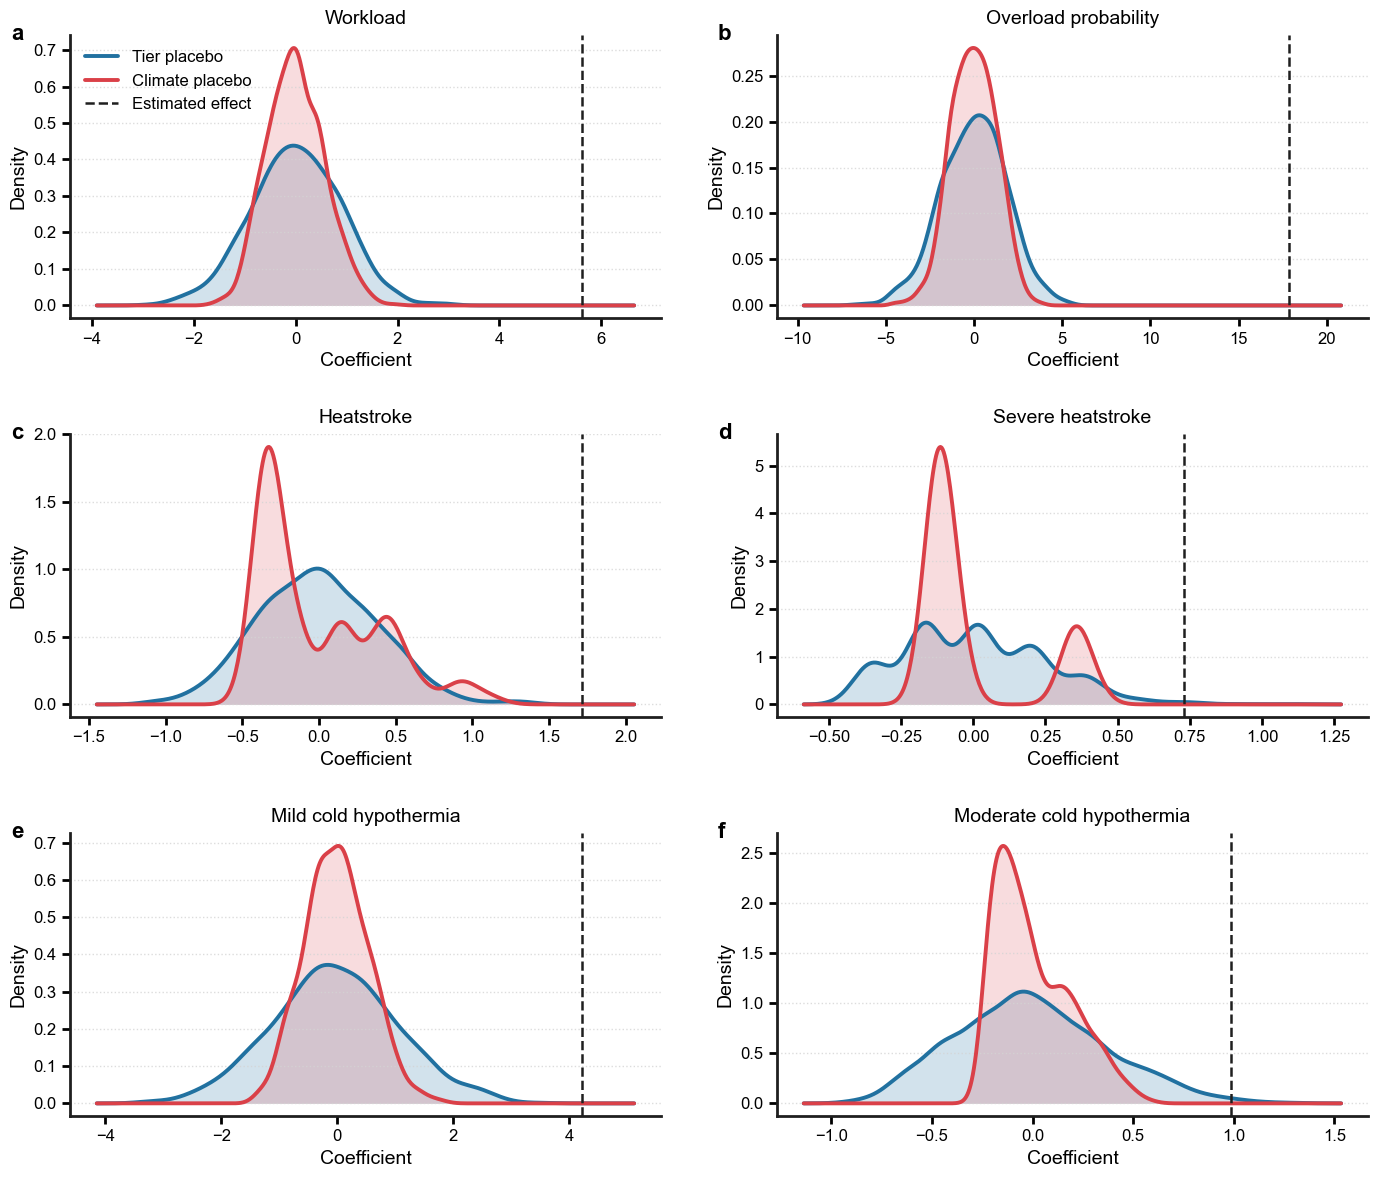

In [1]:
# -*- coding: utf-8 -*-
"""Fig. S6: placebo distributions from randomized tier and climate assignment."""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'lines.solid_capstyle': 'round',
})

TIER_PATH = Path('SI_results') / 'FigS6_Tier.csv'
CLIMATE_PATH = Path('SI_results') / 'FigS6_Climate.csv'
OUTPUT_DIR = Path('SI_Figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTCOMES = [
    ('y11', 'Workload'),
    ('y12', 'Overload probability'),
    ('y23', 'Heatstroke'),
    ('y24', 'Severe heatstroke'),
    ('y33', 'Mild cold hypothermia'),
    ('y34', 'Moderate cold hypothermia'),
]

COLORS = {
    'tier': '#2171A0',
    'tier_fill': (33 / 255, 113 / 255, 160 / 255, 0.20),
    'climate': '#DA4048',
    'climate_fill': (218 / 255, 64 / 255, 72 / 255, 0.18),
    'observed': '#1F1F1F',
    'grid': '#D4D4D4',
    'axis': '#1F1F1F',
}

def read_placebo_csv(path, script_name):
    df = pd.read_csv(path)
    required_cols = {'type', 'rep', 'outcome', 'yvar', 'coef'}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise ValueError(
            f'{path} is incomplete. Missing column(s): {missing_cols}. '
            f'Run {script_name} so it writes the placebo CSV.'
        )
    return df


df_tier = read_placebo_csv(TIER_PATH, 'Statistic_FigS6_tier.do')
df_climate = read_placebo_csv(CLIMATE_PATH, 'Statistic_FigS6_climate.do')

tier_placebo = df_tier[df_tier['type'].eq('placebo')].copy()
climate_placebo = df_climate[df_climate['type'].eq('placebo')].copy()
df_true = pd.concat([
    df_tier[df_tier['type'].eq('true')],
    df_climate[df_climate['type'].eq('true')],
], ignore_index=True).drop_duplicates(subset='yvar', keep='first')

source_vars = [yvar for yvar, _ in OUTCOMES]
missing_tier = sorted(set(source_vars) - set(tier_placebo['yvar']))
missing_climate = sorted(set(source_vars) - set(climate_placebo['yvar']))
missing_true = sorted(set(source_vars) - set(df_true['yvar']))
if missing_tier or missing_climate or missing_true:
    raise KeyError(
        f'Missing outcomes: tier={missing_tier}, climate={missing_climate}, true={missing_true}'
    )

true_effects = df_true.set_index('yvar')['coef'].to_dict()


def kde_curve(values, x_grid):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if values.size < 2 or np.isclose(values.std(), 0):
        return None
    return gaussian_kde(values)(x_grid)


def common_grid(*arrays, n=500):
    values = np.concatenate([pd.Series(arr).dropna().to_numpy(dtype=float) for arr in arrays])
    vmin, vmax = values.min(), values.max()
    pad = 0.12 * (vmax - vmin) if vmax > vmin else 0.1
    return np.linspace(vmin - pad, vmax + pad, n)


fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (ax, (yvar, display_label)) in enumerate(zip(axes, OUTCOMES)):
    tier_values = tier_placebo.loc[tier_placebo['yvar'].eq(yvar), 'coef']
    climate_values = climate_placebo.loc[climate_placebo['yvar'].eq(yvar), 'coef']
    observed_value = true_effects[yvar]
    x_grid = common_grid(tier_values, climate_values, [observed_value])
    tier_density = kde_curve(tier_values, x_grid)
    climate_density = kde_curve(climate_values, x_grid)

    if tier_density is not None:
        ax.plot(x_grid, tier_density, color=COLORS['tier'], linewidth=2.8, label='Tier placebo')
        ax.fill_between(x_grid, 0, tier_density, color=COLORS['tier_fill'], linewidth=0)

    if climate_density is not None:
        ax.plot(x_grid, climate_density, color=COLORS['climate'], linewidth=2.8, label='Climate placebo')
        ax.fill_between(x_grid, 0, climate_density, color=COLORS['climate_fill'], linewidth=0)

    ax.axvline(
        observed_value,
        color=COLORS['observed'],
        linestyle='--',
        linewidth=1.8,
        label='Estimated effect',
        zorder=3,
    )

    ax.set_title(display_label, pad=8)
    ax.set_xlabel('Coefficient')
    ax.set_ylabel('Density')
    ax.grid(axis='y', color=COLORS['grid'], linestyle=':', linewidth=1.0, alpha=0.8)

    ax.text(
        -0.10,
        1.04,
        chr(97 + idx),
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left',
    )

    ax.tick_params(axis='both', which='major', width=2.0, length=6)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(COLORS['axis'])
        ax.spines[spine].set_linewidth(2.0)

    if idx == 0:
        ax.legend(frameon=False, loc='upper left')

fig.tight_layout(w_pad=2.4, h_pad=2.0)
fig.savefig(OUTPUT_DIR / 'FigS6.tiff', format='tiff', dpi=600, bbox_inches='tight')
plt.show()
